# Sprint 4 — EDA: Análisis temporal
**Insumo:** `mvnd_limpio.csv`

### Objetivos
- Tendencia anual 2018–2026 (2026 parcial)
- Estacionalidad mensual
- Evolución de urgencias y tipos de solicitud


##  Configuración


In [1]:
%pip install pandas matplotlib seaborn scipy openpyxl --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import sys

RUTA_LIMPIO = '../datasets/mvnd_limpio.csv'

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 10
sns.set_theme(style='whitegrid', palette='muted')

CARPETA_GRAFICOS = '../graficos/Graficos_eda'
import os
os.makedirs(CARPETA_GRAFICOS, exist_ok=True)

def guardar(fig, nombre):
    ruta = os.path.join(CARPETA_GRAFICOS, nombre)
    fig.savefig(ruta, dpi=150, bbox_inches='tight')
    print(f' Guardado: {ruta}')



[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [2]:
df = pd.read_csv(RUTA_LIMPIO, encoding='utf-8-sig')
df['FECHA_AUTORIZACION'] = pd.to_datetime(df['FECHA_AUTORIZACION'])

# Corregir nombre de columna año parcial (encoding en CSV)
for c in list(df.columns):
    if 'PARCIAL' in c.upper():
        df = df.rename(columns={c: 'ANIO_PARCIAL'})

print(f' Dataset cargado: {len(df):,} registros × {df.shape[1]} columnas')
print(f'   Período: {df["FECHA_AUTORIZACION"].min().date()} → {df["FECHA_AUTORIZACION"].max().date()}')


 Dataset cargado: 9,413 registros × 21 columnas
   Período: 2018-01-09 → 2026-06-12


## 1. Evolución anual


 Guardado: ../graficos/Graficos_eda\06_evolucion_anual.png


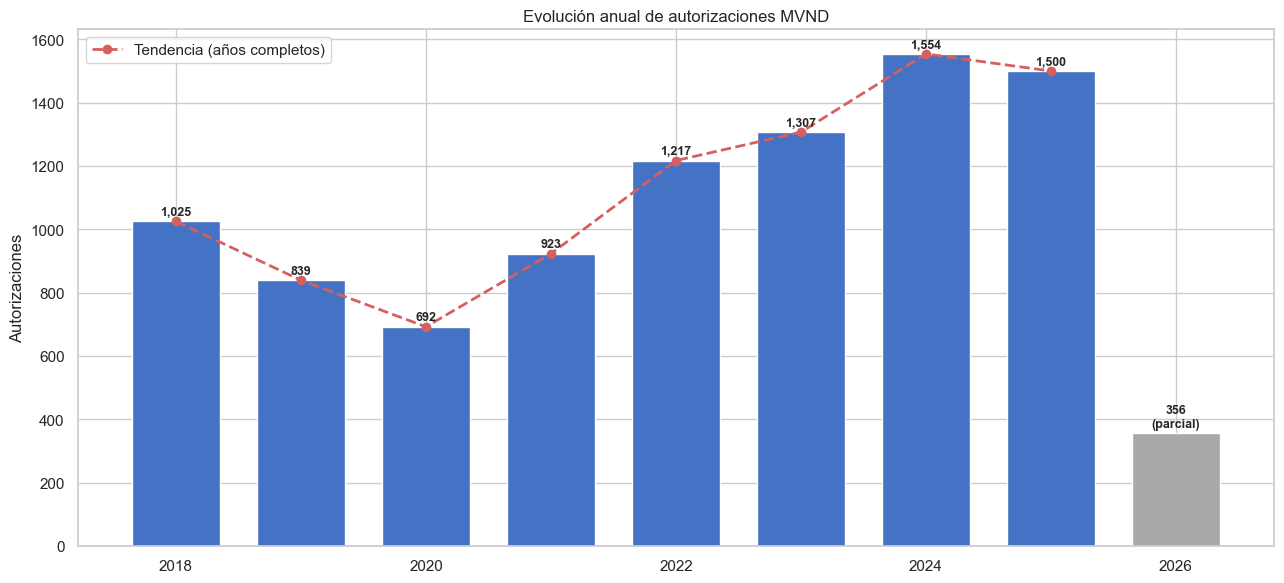

 ANIO  Autorizaciones  Parcial      Var_%
 2018            1025    False        NaN
 2019             839    False -18.146341
 2020             692    False -17.520858
 2021             923    False  33.381503
 2022            1217    False  31.852654
 2023            1307    False   7.395234
 2024            1554    False  18.898240
 2025            1500    False  -3.474903
 2026             356     True -76.266667

Crecimiento 2018→2024: 51.6%


In [3]:

anual = df.groupby('ANIO', as_index=False).size().rename(columns={'size': 'Autorizaciones'})
anual['Parcial'] = anual['ANIO'] == anual['ANIO'].max()

fig, ax = plt.subplots(figsize=(13, 6))
colores = ['#a9a9a9' if p else '#4472C4' for p in anual['Parcial']]
ax.bar(anual['ANIO'], anual['Autorizaciones'], color=colores, width=0.7)
for _, row in anual.iterrows():
    lbl = f"{row['Autorizaciones']:,}\n(parcial)" if row['Parcial'] else f"{row['Autorizaciones']:,}"
    ax.text(row['ANIO'], row['Autorizaciones']+20, lbl, ha='center', fontsize=9, fontweight='bold')
comp = anual[~anual['Parcial']]
ax.plot(comp['ANIO'], comp['Autorizaciones'], 'ro--', linewidth=2, label='Tendencia (años completos)')
ax.set_title('Evolución anual de autorizaciones MVND')
ax.set_ylabel('Autorizaciones')
ax.legend()
plt.tight_layout()
guardar(plt.gcf(), '06_evolucion_anual.png')
plt.show()

anual['Var_%'] = anual['Autorizaciones'].pct_change() * 100
print(anual.to_string(index=False))
c18, c24 = anual.loc[anual['ANIO']==2018,'Autorizaciones'].iloc[0], anual.loc[anual['ANIO']==2024,'Autorizaciones'].iloc[0]
print(f'\nCrecimiento 2018→2024: {(c24-c18)/c18*100:.1f}%')



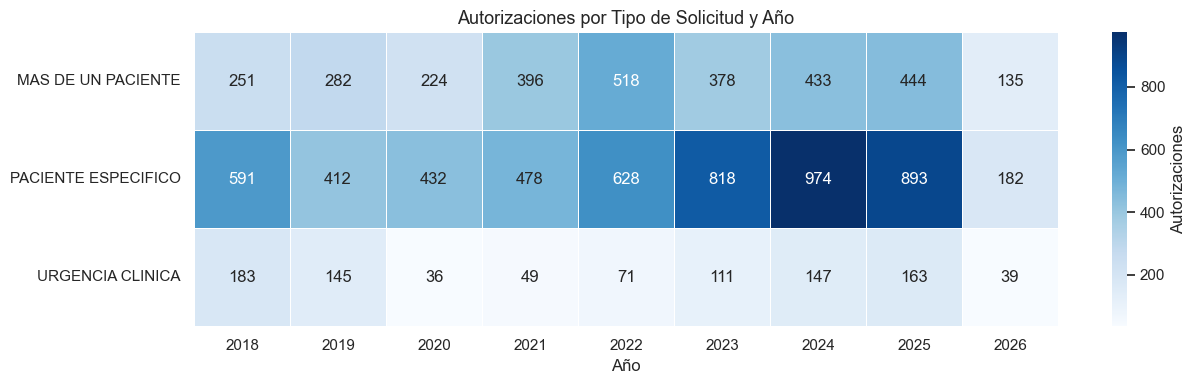

In [16]:
# ─── Heatmap: Tipo de solicitud por año ─────────────────────────────────────
pivot = df.pivot_table(index='TIPO_SOLICITUD', columns='ANIO',
                        values='PRINCIPIO_ACTIVO', aggfunc='count')

fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='Blues', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Autorizaciones'})
ax.set_title('Autorizaciones por Tipo de Solicitud y Año', fontsize=13)
ax.set_xlabel('Año')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('../graficos/Graficos_eda/06_grafico_heatmap_tipo_anio.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Estacionalidad mensual (2018–2025)


 Guardado: ../graficos/Graficos_eda\06_estacionalidad_mensual.png


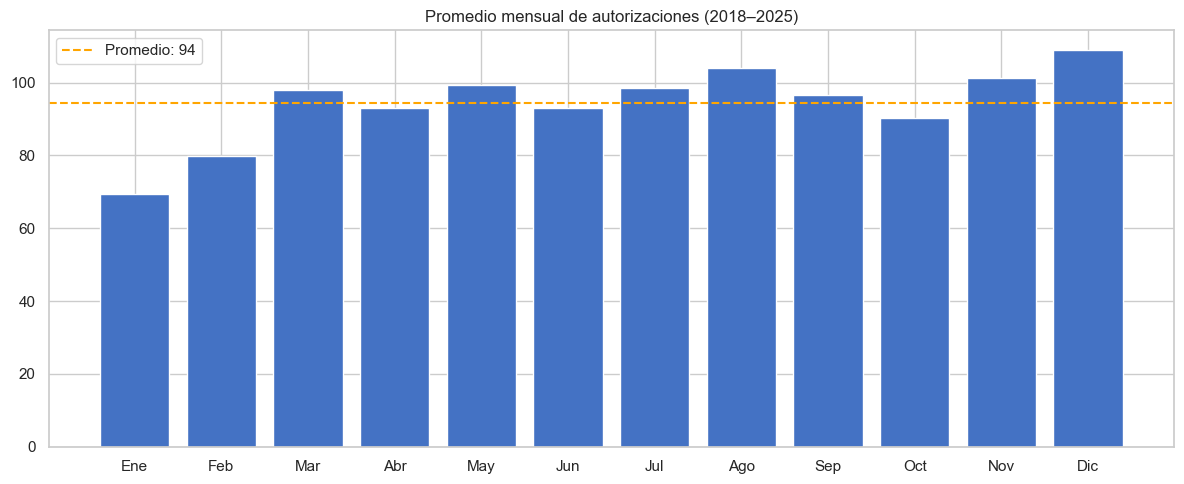

In [10]:

df_comp = df[df['ANIO'] <= 2025]
mensual = df_comp.groupby('MES').size() / df_comp['ANIO'].nunique()
meses = {1:'Ene',2:'Feb',3:'Mar',4:'Abr',5:'May',6:'Jun',7:'Jul',8:'Ago',9:'Sep',10:'Oct',11:'Nov',12:'Dic'}

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar([meses[m] for m in mensual.index], mensual.values, color='#4472C4')
ax.axhline(mensual.mean(), color='orange', linestyle='--', label=f'Promedio: {mensual.mean():.0f}')
ax.set_title('Promedio mensual de autorizaciones (2018–2025)')
ax.legend()
plt.tight_layout()
guardar(plt.gcf(), '06_estacionalidad_mensual.png')
plt.show()



## 3. Trimestral


 Guardado: ../graficos/Graficos_eda\06_heatmap_trimestral.png


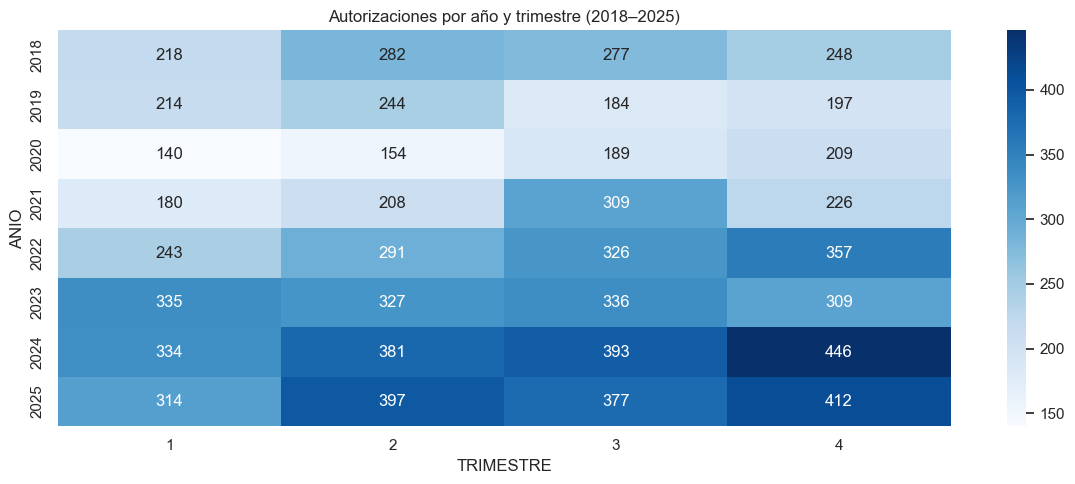

In [11]:

trim = df[df['ANIO'] <= 2025].groupby(['ANIO','TRIMESTRE']).size().unstack(fill_value=0)
fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(trim, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_title('Autorizaciones por año y trimestre (2018–2025)')
plt.tight_layout()
guardar(plt.gcf(), '06_heatmap_trimestral.png')
plt.show()



## 4. Tipo de solicitud por año


 Guardado: ../graficos/Graficos_eda\06_tipo_solicitud_anual.png


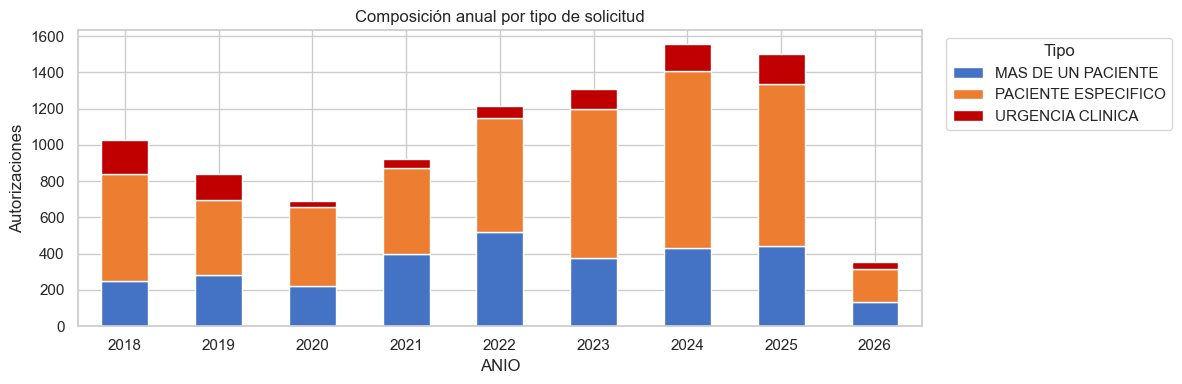

In [12]:

pivot = pd.crosstab(df['ANIO'], df['TIPO_SOLICITUD'])
fig, ax = plt.subplots(figsize=(12, 4))
pivot.plot(kind='bar', stacked=True, ax=ax, color=['#4472C4','#ED7D31','#c00000'])
ax.set_title('Composición anual por tipo de solicitud')
ax.set_ylabel('Autorizaciones')
ax.legend(title='Tipo', bbox_to_anchor=(1.02, 1))
plt.xticks(rotation=0)
plt.tight_layout()
guardar(plt.gcf(), '06_tipo_solicitud_anual.png')
plt.show()



## 5. Urgencias clínicas en el tiempo


 Guardado: ../graficos/Graficos_eda\06_urgencias_anuales.png


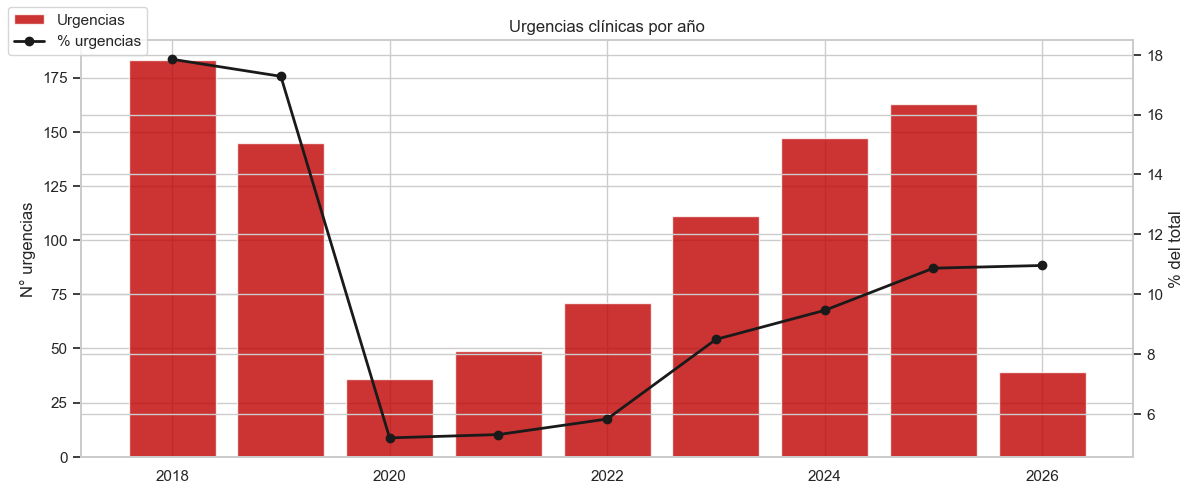

      total  urgencias  pct_urgencia
ANIO                                
2018   1025        183         17.85
2019    839        145         17.28
2020    692         36          5.20
2021    923         49          5.31
2022   1217         71          5.83
2023   1307        111          8.49
2024   1554        147          9.46
2025   1500        163         10.87
2026    356         39         10.96


In [13]:

urg_anual = df.groupby('ANIO').agg(
    total=('ES_URGENCIA','count'),
    urgencias=('ES_URGENCIA','sum')
)
urg_anual['pct_urgencia'] = (urg_anual['urgencias'] / urg_anual['total'] * 100).round(2)

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.bar(urg_anual.index, urg_anual['urgencias'], color='#c00000', alpha=0.8, label='Urgencias')
ax1.set_ylabel('N° urgencias')
ax2 = ax1.twinx()
ax2.plot(urg_anual.index, urg_anual['pct_urgencia'], 'ko-', linewidth=2, label='% urgencias')
ax2.set_ylabel('% del total')
ax1.set_title('Urgencias clínicas por año')
fig.legend(loc='upper left')
plt.tight_layout()
guardar(plt.gcf(), '06_urgencias_anuales.png')
plt.show()
print(urg_anual)



## 6. Top 3 medicamentos — tendencia anual


 Guardado: ../graficos/Graficos_eda\06_tendencia_top3_medicamentos.png


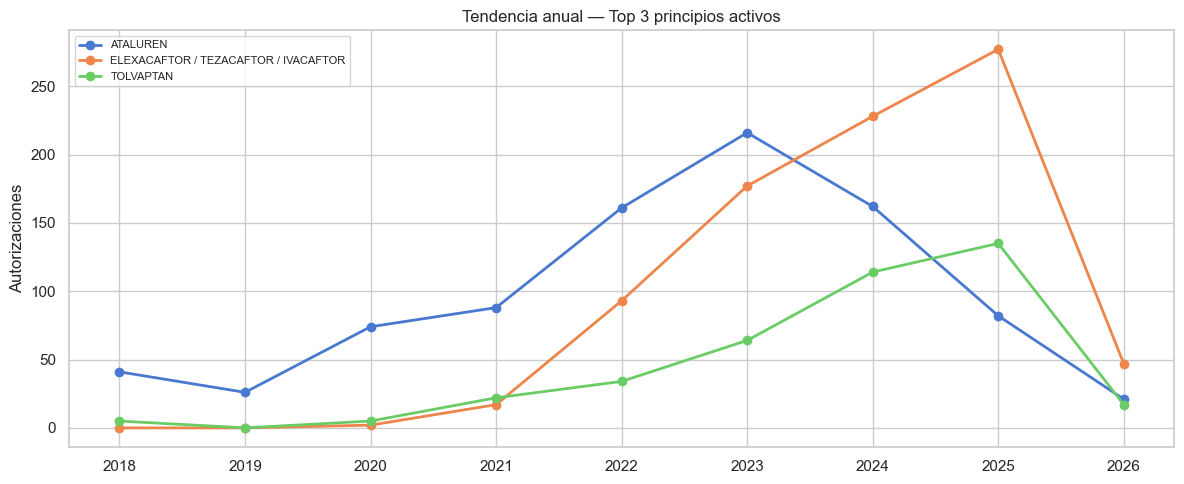

In [14]:

top3 = df['PRINCIPIO_ACTIVO'].value_counts().head(3).index
trend = df[df['PRINCIPIO_ACTIVO'].isin(top3)].groupby(['ANIO','PRINCIPIO_ACTIVO']).size().unstack(fill_value=0)
fig, ax = plt.subplots(figsize=(12, 5))
for col in trend.columns:
    ax.plot(trend.index, trend[col], marker='o', linewidth=2, label=col[:40])
ax.set_title('Tendencia anual — Top 3 principios activos')
ax.set_ylabel('Autorizaciones')
ax.legend(fontsize=8)
plt.tight_layout()
guardar(plt.gcf(), '06_tendencia_top3_medicamentos.png')
plt.show()



##  Hallazgos — Sprint 4 (Temporal)

| Hallazgo | Evidencia |
|----------|-----------|
| Tendencia creciente | Aumento sostenido 2018–2024 (~+61%) |
| 2026 parcial | Solo enero–abril; no comparar con años completos |
| Estacionalidad | Meses con mayor promedio identificables en 2018–2025 |
| Urgencias | Proporción relativamente estable (~9,5% global) con variación anual |

**Siguiente:** `07_Analisis_Estadistico.ipynb`
